# 05. Focal Loss

Weighted loss assigns a fixed penalty multiplier per class based on frequency. Every N sample always gets weight 0.22, every F sample always gets weight 24.6, regardless of how well the model is doing on them.
Focal loss is dynamic. It looks at how confident the model is on each individual sample and down-weights the loss for samples the model already handles well — regardless of class.
The key term is pt — the model's predicted probability for the correct class:

If pt is high (say 0.95) — the model is confident and correct. Focal loss says "this sample is easy, barely penalize it"
If pt is low (say 0.05) — the model is wrong or uncertain. Focal loss says "this sample is hard, penalize it more"

The formula:
Focal Loss = -(1 - pt)^gamma * log(pt)
When pt is high, (1 - pt)^gamma approaches zero — easy samples contribute almost nothing to the loss. When pt is low, (1 - pt)^gamma approaches 1 — hard samples contribute fully.
gamma controls how aggressively you down-weight easy samples:

gamma=0 → identical to standard cross entropy
gamma=1 → mild focusing
gamma=2 → standard recommendation from the original paper

The intuition: instead of telling the model "F beats matter more because there are fewer of them", focal loss tells the model "focus on whatever you're currently getting wrong." In a class imbalanced dataset those end up being the same thing — the model gets N right easily, so N samples get down-weighted automatically.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

Added to losses.py

## Load Data

In [2]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from src.model import ECGNet

# load
npz = np.load('../data/processed/beats_split.npz')
X_train = torch.tensor(npz['X_train']).unsqueeze(1)  # (N, 1, 360)
y_train = torch.tensor(npz['y_train'])
X_test  = torch.tensor(npz['X_test']).unsqueeze(1)
y_test  = torch.tensor(npz['y_test'])

print(X_train.shape, y_train.shape)
print(X_test.shape,  y_test.shape)

torch.Size([50995, 1, 360]) torch.Size([50995])
torch.Size([49687, 1, 360]) torch.Size([49687])


In [3]:
train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 797
Test batches:  777


## Training Loop

In [4]:
from torch import nn
from src.losses import FocalLoss

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model     = ECGNet().to(device)

criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f'Device: {device}')

Device: mps


In [5]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # 1. move to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # 2. zero gradients
        optimizer.zero_grad()
        # 3. forward pass
        y_pred = model(X_batch)
        # 4. compute loss
        loss = criterion(y_pred, y_batch)
        # 5. backward pass
        loss.backward()
        # 6. optimizer step
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    

Epoch [1/10], Loss: 0.1782
Epoch [2/10], Loss: 0.1532
Epoch [3/10], Loss: 0.1432
Epoch [4/10], Loss: 0.1283
Epoch [5/10], Loss: 0.1152
Epoch [6/10], Loss: 0.1075
Epoch [7/10], Loss: 0.1023
Epoch [8/10], Loss: 0.0978
Epoch [9/10], Loss: 0.0938
Epoch [10/10], Loss: 0.0914


## Evaluation

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
from src.data_loader import CLASS_NAMES

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

              precision    recall  f1-score   support

           N       0.92      0.99      0.95     44235
           S       0.15      0.00      0.01      1837
           V       0.68      0.48      0.57      3220
           F       0.00      0.00      0.00       388
           Q       0.00      0.00      0.00         7

    accuracy                           0.91     49687
   macro avg       0.35      0.29      0.30     49687
weighted avg       0.87      0.91      0.89     49687



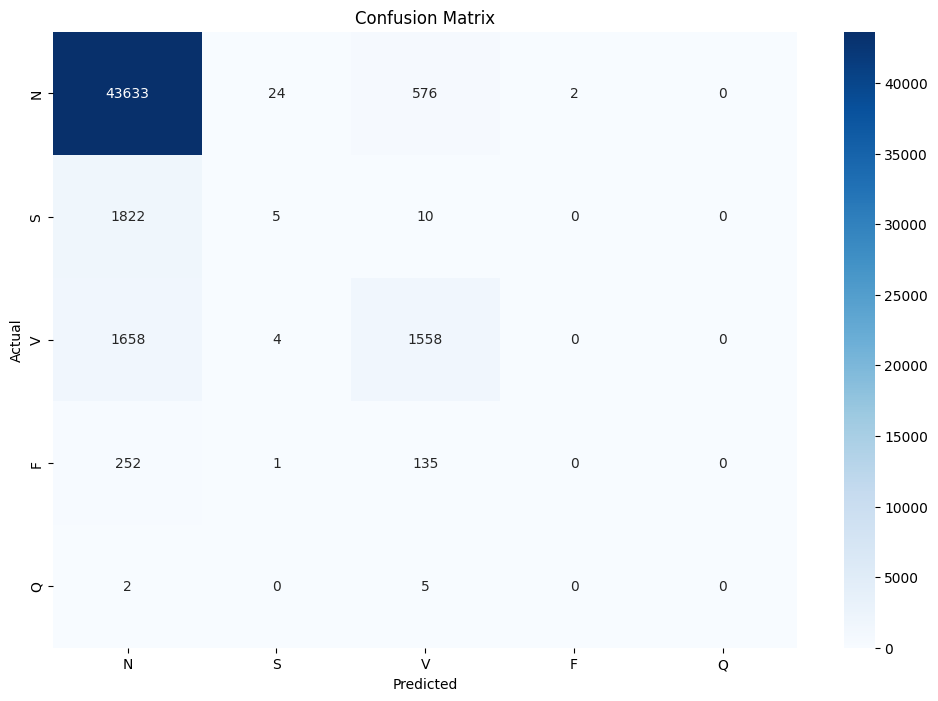

In [7]:
# PLot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('../results/focal_loss_cm_raw.png', dpi=150, bbox_inches='tight')
plt.show()

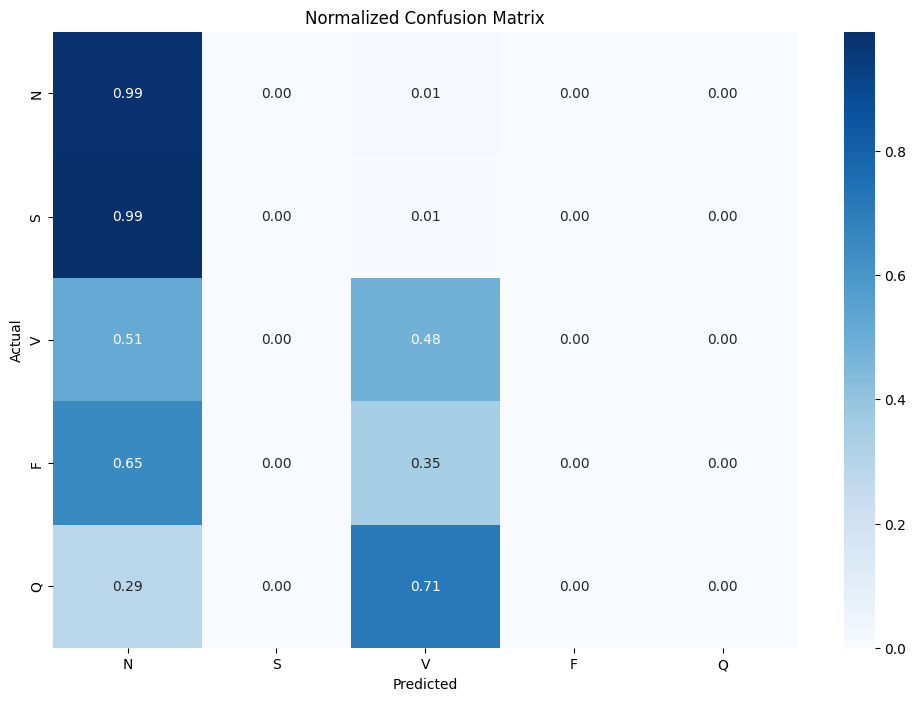

In [8]:
# PLot normalized confusion matrix

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.savefig('../results/focal_loss_cm_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

# Weighted Focal Loss

Weighted loss fixes the frequency problem — rare classes get higher penalty multipliers. But it applies the same weight to every F beat regardless of whether the model finds that particular beat easy or hard.
Focal loss fixes the difficulty problem — easy samples get suppressed dynamically. But with extreme imbalance, the sheer volume of easy N samples still dominates even with gamma=2.
Combined — you get both corrections simultaneously:

The alpha weights (like weighted loss) ensure rare classes have higher base penalty
The gamma term further suppresses the easy N samples within that weighted loss

The formula becomes:
Focal Loss = -alpha_t * (1 - pt)^gamma * log(pt)
Where alpha_t is the class weight for the correct class of that sample. So a rare F beat that the model gets wrong gets hit with both a high alpha weight AND a high focal term. Double pressure on the hard, rare cases.

In [15]:
from torch import nn
from src.losses import FocalLoss
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model     = ECGNet().to(device)
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3, 4]),
    y=y_train.numpy()
)
weights = np.clip(weights, 0, 5)
weight_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = FocalLoss(gamma=2.0, alpha=weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f'Device: {device}')

Device: mps


In [16]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # 1. move to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # 2. zero gradients
        optimizer.zero_grad()
        # 3. forward pass
        y_pred = model(X_batch)
        # 4. compute loss
        loss = criterion(y_pred, y_batch)
        # 5. backward pass
        loss.backward()
        # 6. optimizer step
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    

Epoch [1/10], Loss: 0.3139
Epoch [2/10], Loss: 0.2608
Epoch [3/10], Loss: 0.2309
Epoch [4/10], Loss: 0.2144
Epoch [5/10], Loss: 0.1995
Epoch [6/10], Loss: 0.1877
Epoch [7/10], Loss: 0.1785
Epoch [8/10], Loss: 0.1712
Epoch [9/10], Loss: 0.1634
Epoch [10/10], Loss: 0.1575


## Evaluation

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
from src.data_loader import CLASS_NAMES

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

              precision    recall  f1-score   support

           N       0.99      0.16      0.28     44235
           S       0.06      0.78      0.12      1837
           V       0.21      0.78      0.33      3220
           F       0.02      0.34      0.03       388
           Q       0.00      0.00      0.00         7

    accuracy                           0.23     49687
   macro avg       0.26      0.41      0.15     49687
weighted avg       0.89      0.23      0.28     49687

